# Fundamentos de Deep Learning con `Keras` (`TensorFlow`) — Sesión 3  
## Bloques 5 y 6: fundamentos de Deep Learning, aprendizaje y primeras implementaciones

**Objetivo del cuaderno**  
Este notebook está pensado como continuación natural de los dos cuadernos anteriores del módulo:

- **Sesión 1**: fundamentos de ML clásico y regresión con `scikit-learn`.
- **Sesión 2**: clasificación, validación y evaluación con `scikit-learn`.

Ahora damos el salto a **Deep Learning**, pero **sin romper la continuidad** con lo ya aprendido.  
La idea no es presentar las redes neuronales como "magia", sino como una familia de modelos que:

- sigue necesitando datos, particiones y métricas,
- sigue necesitando validación y sentido crítico,
- pero introduce una nueva forma de construir el modelo y de entrenarlo.

A lo largo del notebook veremos con calma:

- qué es una neurona artificial,
- qué son los **pesos**, el **sesgo** y las **funciones de activación**,
- qué significa que una red "aprenda",
- qué papel juegan la **función de pérdida**, el **optimizador**, las **épocas** y los **batches**,
- cómo se relaciona todo esto con ideas que ya conocíamos, como **bias vs variance**,
- y cómo implementar redes sencillas en `Keras`.

Trabajaremos con tres ejemplos muy asequibles:

1. **Regresión tabular** con el dataset `diabetes` de `scikit-learn`.
2. **Clasificación tabular** con el dataset `breast_cancer` de `scikit-learn`.
3. **CNN para imágenes** con **MNIST** usando `tf.keras.datasets`.

> **Filosofía del notebook**  
> Igual que en los cuadernos anteriores, aquí habrá mucho más que código:
> queremos entender **qué estamos haciendo**, **por qué lo hacemos** y **cómo leer los resultados**.

## Hoja de ruta

### Parte A — Conectar ML clásico con Deep Learning
1. Qué se mantiene al pasar de `scikit-learn` a `Keras`.
2. Qué cambia realmente cuando entramos en redes neuronales.
3. Neurona artificial, pesos, sesgo y activación.
4. Capas densas y perceptrón multicapa.
5. Tensores y formas (`shape`).
6. API mental de `Keras`.

### Parte B — Cómo aprende una red neuronal
7. Predicción, error y función de pérdida.
8. Descenso de gradiente.
9. Épocas, batches y validación.
10. Optimizadores y métricas.
11. Bias vs variance en Deep Learning.
12. Regularización y `EarlyStopping`.

### Parte C — Ejemplo 1: regresión con Keras
13. Carga y preparación de datos.
14. Baseline clásico para mantener la conexión con `scikit-learn`.
15. Red neuronal densa para regresión.
16. Curvas de entrenamiento e interpretación.

### Parte D — Ejemplo 2: clasificación con Keras
17. Problema de clasificación binaria.
18. Red neuronal con salida sigmoide.
19. Pérdida, accuracy y umbral de decisión.
20. Evaluación detallada.

### Parte E — Ejemplo 3: CNN con MNIST
21. Por qué las imágenes piden otro tipo de red.
22. Capas convolucionales y `pooling`.
23. Entrenamiento de una CNN sencilla.
24. Evaluación final y lectura de errores.

### Parte F — Cierre
25. Ideas clave para llevarse de esta sesión.
26. Ejercicios propuestos.

# Parte A. De `scikit-learn` a `Keras`: qué sigue igual y qué cambia

## 1. Lo que **sí** se mantiene respecto a `scikit-learn`

Aunque cambiemos de librería y de familia de modelos, muchas ideas **siguen siendo exactamente las mismas**:

- seguimos teniendo unas variables de entrada `X` y una variable objetivo `y`,
- seguimos separando entrenamiento, validación y test,
- seguimos necesitando métricas,
- seguimos queriendo generalizar bien a datos no vistos,
- seguimos pudiendo caer en **underfitting** y **overfitting**,
- y seguimos necesitando una forma de comparar modelos de manera razonable.

Esto es importantísimo:  
**Deep Learning no sustituye la lógica del Machine Learning; la amplía**.

Por eso, durante toda esta sesión iremos conectando constantemente con lo visto en `scikit-learn`.

## 2. Lo que cambia al entrar en Deep Learning

Lo que cambia no es la idea general del aprendizaje supervisado, sino sobre todo:

### a) La forma de construir el modelo
En `scikit-learn` solemos elegir un estimador ya preparado:

- `LinearRegression`
- `LogisticRegression`
- `RandomForestClassifier`
- `KNeighborsRegressor`

En `Keras`, en cambio, **nosotros definimos la arquitectura** de la red:

- cuántas capas tendrá,
- cuántas neuronas tendrá cada capa,
- qué activaciones usar,
- y cómo queremos entrenarla.

### b) La forma de entrenar
En modelos clásicos muchas veces el ajuste interno queda "escondido" detrás de `fit`.

En redes neuronales también usamos `fit`, pero el entrenamiento está mucho más ligado a:

- función de pérdida,
- gradientes,
- optimizador,
- tamaño de batch,
- número de épocas,
- regularización.

### c) La dependencia del preprocesado
En datos tabulares, las redes suelen agradecer mucho:

- entradas numéricas,
- escalado razonable,
- y cierta estabilidad en la magnitud de las variables.

### d) El coste computacional
Las redes neuronales, especialmente al crecer, suelen ser más costosas de entrenar que muchos modelos clásicos.

## 3. La neurona artificial: la pieza básica

La idea básica de una neurona artificial es sorprendentemente sencilla.

Imagina que tenemos varias entradas:

- `x1`
- `x2`
- `x3`
- ...

Cada entrada se multiplica por un **peso**:

- `w1`
- `w2`
- `w3`
- ...

Después, se suma todo y se añade un **sesgo** o **bias**:

\[
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
\]

A continuación, ese valor pasa por una **función de activación**.

La activación introduce **no linealidad**, y eso es crucial.  
Si encadenáramos solo operaciones lineales, toda la red equivaldría a una sola transformación lineal.

## 4. Pesos, sesgo y activación

### Pesos
Los pesos indican cuánto influye cada entrada en la salida de la neurona.

### Sesgo (`bias`)
El sesgo permite desplazar la salida; es parecido a la ordenada en el origen en una recta.

### Función de activación
La activación transforma el resultado intermedio.

Activaciones típicas:

- **ReLU**: muy común en capas ocultas.
- **sigmoid**: frecuente en salida binaria.
- **softmax**: típica en clasificación multiclase.

La idea intuitiva es que la activación permite que la red aprenda relaciones complejas y no meramente lineales.

## 5. Del perceptrón a una red multicapa

Una sola neurona es muy limitada.

Si apilamos muchas neuronas en **capas** obtenemos una red neuronal:

- **capa de entrada**: recibe las variables,
- **capas ocultas**: transforman la información,
- **capa de salida**: produce la predicción final.

Cuando usamos varias capas densamente conectadas hablamos de una **MLP** (*Multi-Layer Perceptron*).

En una capa densa, cada neurona recibe información de todas las neuronas de la capa anterior.

## 6. ¿Qué significa "densa" en `Keras`?

En `Keras`, la capa densa se implementa con:

```python
tf.keras.layers.Dense(...)
```

Una capa densa hace esencialmente esto:

1. toma la entrada,
2. aplica una transformación afín (pesos + sesgo),
3. aplica una activación.

Si ponemos varias `Dense` una detrás de otra, estamos construyendo una MLP.

## 7. Tensores y formas (`shape`)

En `scikit-learn` hablábamos sobre todo de arrays y matrices `numpy`.

En Deep Learning también trabajamos con arrays, pero se usa mucho el término **tensor**.

No hace falta darle demasiada épica:
un tensor es, en la práctica, una estructura numérica con varias dimensiones.

Ejemplos:

- vector: forma `(n_features,)`
- lote de ejemplos tabulares: forma `(batch_size, n_features)`
- lote de imágenes en gris: forma `(batch_size, alto, ancho, canales)`

Entender la **forma** de los datos es fundamental, porque una gran parte de los errores en Deep Learning vienen de incompatibilidades de forma.

## 8. Salidas típicas según el problema

### Regresión
Queremos un número continuo.

Suele usarse:
- una sola neurona de salida,
- sin activación especial o con activación lineal,
- pérdidas como `mse` o `mae`.

### Clasificación binaria
Queremos distinguir entre dos clases.

Suele usarse:
- una neurona de salida,
- activación `sigmoid`,
- pérdida `binary_crossentropy`.

### Clasificación multiclase
Queremos una de varias clases.

Suele usarse:
- una neurona por clase,
- activación `softmax`,
- pérdida `sparse_categorical_crossentropy` o `categorical_crossentropy`.

## 9. API mental de `Keras`

En `scikit-learn`, nuestra API mental era algo así:

- crear transformadores,
- crear estimadores,
- `fit`,
- `predict`,
- `score` o métricas aparte.

En `Keras`, una API mental muy útil es esta:

1. **Definir el modelo**  
   con `Sequential` o con la API funcional.
2. **Compilarlo**  
   indicando:
   - optimizador,
   - pérdida,
   - métricas.
3. **Entrenarlo**  
   con `fit(...)`.
4. **Evaluarlo**  
   con `evaluate(...)`.
5. **Predecir**  
   con `predict(...)`.

Es decir:

```python
model = keras.Sequential([...])
model.compile(...)
history = model.fit(...)
model.evaluate(...)
preds = model.predict(...)
```

## 10. `compile`, `fit`, `evaluate`, `predict`

### `compile`
Aquí le decimos a la red **cómo queremos entrenarla**:

- qué optimizador usar,
- qué pérdida minimizar,
- qué métricas mostrar.

### `fit`
Aquí ocurre el aprendizaje iterativo.

### `evaluate`
Sirve para medir el rendimiento en un conjunto dado, normalmente el de test.

### `predict`
Devuelve predicciones numéricas.  
En clasificación, luego podemos transformarlas en clases si hace falta.

# Parte B. ¿Cómo aprende una red neuronal?

## 11. Predicción, error y función de pérdida

Cada vez que la red recibe un ejemplo:

1. produce una predicción,
2. comparamos esa predicción con el valor real,
3. medimos el error con una **función de pérdida**.

La pérdida es la magnitud que intentamos **minimizar** durante el entrenamiento.

Ejemplos:

- en regresión: `mse`, `mae`
- en clasificación binaria: `binary_crossentropy`
- en clasificación multiclase: `sparse_categorical_crossentropy`

**Idea clave**:  
la pérdida es la brújula que guía el aprendizaje.

## 12. Descenso de gradiente: intuición

La red tiene muchos parámetros: pesos y sesgos.

El objetivo es encontrar valores de esos parámetros que hagan pequeña la pérdida.

La idea intuitiva del **descenso de gradiente** es:

- mirar en qué dirección la pérdida disminuye,
- mover ligeramente los parámetros en esa dirección,
- repetir muchas veces.

No vamos a derivar toda la matemática aquí, pero sí conviene quedarse con esta imagen mental:

> la red empieza "desordenada", comete errores, mide esos errores y va ajustando sus pesos poco a poco para cometer menos.

Ese ajuste iterativo es la esencia del aprendizaje en Deep Learning.

## 13. Épocas, batches y pasos de entrenamiento

Estos tres conceptos aparecen todo el rato.

### Época (`epoch`)
Una época es una **pasada completa** por todo el conjunto de entrenamiento.

### Batch
En vez de actualizar los pesos ejemplo a ejemplo o con todos los datos a la vez, solemos agrupar los datos en pequeños lotes llamados **batches**.

### Paso de entrenamiento
Cada batch genera una actualización de pesos.

Si tenemos 10.000 ejemplos y un `batch_size=32`, una época contendrá aproximadamente:

\[
\frac{10000}{32} \approx 313
\]

pasos de actualización.

### ¿Por qué no usar todo a la vez?
Porque trabajar por batches:

- reduce memoria,
- introduce una cierta variabilidad útil,
- y suele hacer el entrenamiento más manejable.

## 14. Validación durante el entrenamiento

En los cuadernos de `scikit-learn` ya vimos que no basta con mirar el rendimiento sobre entrenamiento.

En `Keras` podemos pedir a `fit` que vaya evaluando la red sobre un conjunto de validación al final de cada época.

Esto nos permite observar:

- si la pérdida de entrenamiento baja,
- si la de validación también baja,
- o si llega un momento en que el modelo empieza a **sobreajustar**.

Esta lectura de curvas es una parte central del trabajo con redes neuronales.

## 15. Optimizadores

El optimizador decide **cómo** se actualizan los pesos.

Dos nombres muy frecuentes:

- **SGD** (*Stochastic Gradient Descent*)
- **Adam**

### Intuición práctica
- `SGD` es más "clásico" y a veces más simple de interpretar.
- `Adam` suele ser una opción muy cómoda y robusta para empezar.

En un curso introductorio, usar `Adam` como optimizador por defecto es una decisión totalmente razonable.

## 16. Métricas frente a pérdida

Esto ya lo vimos en `scikit-learn`, y aquí vuelve a ser muy importante.

### Pérdida
Es lo que el optimizador intenta minimizar.

### Métrica
Es una forma de evaluar el rendimiento con un criterio que nos resulte interpretable.

Ejemplos:

- en regresión:
  - pérdida: `mse`
  - métrica: `mae`
- en clasificación:
  - pérdida: `binary_crossentropy`
  - métrica: `accuracy`

A veces la pérdida y la métrica apuntan en la misma dirección.  
Otras veces conviene mirar varias métricas para no simplificar demasiado la lectura del modelo.

## 17. Bias vs variance en redes neuronales

Las ideas de **underfitting** y **overfitting** siguen vivísimas aquí.

### Modelo con demasiado sesgo (*high bias*)
- demasiado simple,
- no aprende bien ni siquiera entrenamiento,
- entrenamiento y validación salen ambos mal.

### Modelo con demasiada varianza (*high variance*)
- aprende mucho el entrenamiento,
- pero generaliza mal,
- entrenamiento muy bien y validación peor.

En Deep Learning, el riesgo de varianza alta puede ser importante porque las redes tienen mucha capacidad.

Por eso tienen tanta relevancia cosas como:

- validación,
- regularización,
- `dropout`,
- `EarlyStopping`,
- y una arquitectura razonable para el tamaño del problema.

## 18. Regularización y `EarlyStopping`

### Regularización
Son técnicas pensadas para mejorar la generalización.

Ejemplos:
- penalizaciones sobre pesos,
- `dropout`,
- simplificar la arquitectura,
- más datos,
- data augmentation en visión.

### `EarlyStopping`
Es una técnica muy práctica:  
si la validación deja de mejorar, paramos el entrenamiento antes de seguir memorizando ruido.

Pedagógicamente, `EarlyStopping` es muy interesante porque conecta perfectamente con la idea de controlar el overfitting.

## 19. Tres ideas que quiero que te lleves antes de programar

1. Una red neuronal **no** es magia: es una composición de capas con pesos entrenables.
2. Aprender significa **ajustar pesos para reducir una pérdida**.
3. La lectura de curvas, métricas y validación importa tanto como en `scikit-learn`, o incluso más.

# Parte C. Ejemplo 1 — Regresión tabular con `Keras`

## 20. Dataset de regresión: `diabetes`

Vamos a usar el dataset `diabetes` que viene con `scikit-learn`.

¿Por qué es una buena elección para empezar?

- es pequeño,
- es tabular,
- viene ya listo para usar,
- y nos permite centrarnos en la lógica de la red sin pelear con la obtención de datos.

Además, conecta muy bien con la sesión 1, donde ya trabajamos problemas de regresión tabular.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
diabetes = load_diabetes(as_frame=True)
df_reg = diabetes.frame.copy()

print(df_reg.shape)
df_reg.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 21. Entender mínimamente qué tenemos entre manos

Antes de entrenar nada, recordemos una costumbre sana de `scikit-learn` que también queremos mantener aquí:

- mirar el tamaño,
- mirar columnas,
- mirar el target,
- mirar rangos y distribuciones,
- y pensar si hace falta escalar.

En redes neuronales tabulares, el **escalado** suele ser especialmente recomendable.

In [4]:
df_reg.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


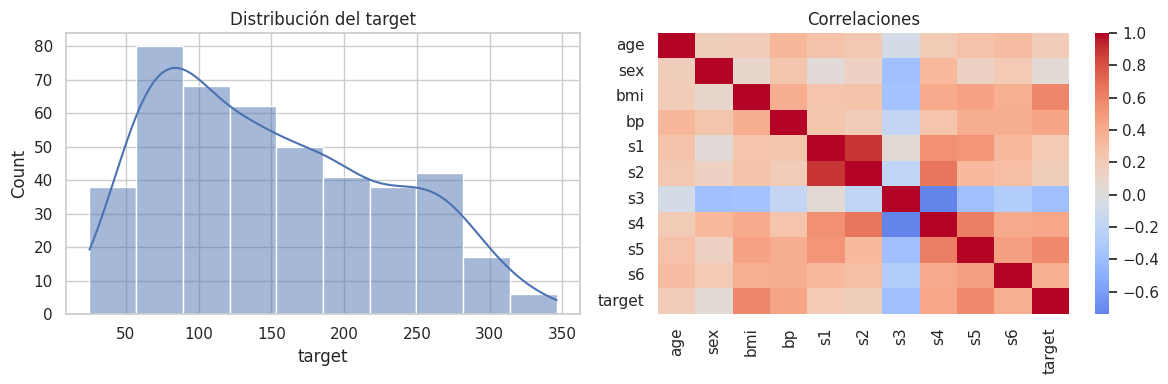

In [5]:
X_reg = df_reg.drop(columns="target")
y_reg = df_reg["target"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_reg, kde=True, ax=ax[0])
ax[0].set_title("Distribución del target")

sns.heatmap(df_reg.corr(numeric_only=True), cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Correlaciones")
plt.tight_layout()
plt.show()

## 22. Train, validation y test en Deep Learning

Igual que antes:

- **train**: para aprender,
- **validation**: para vigilar el entrenamiento,
- **test**: para evaluación final honesta.

Aquí haremos una división explícita en dos pasos:

1. primero separaremos **test**,
2. luego separaremos una parte de entrenamiento para **validation**.

In [6]:
X_train_full_reg, X_test_reg, y_train_full_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_train_full_reg, y_train_full_reg, test_size=0.20, random_state=42
)

print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Validation:", X_val_reg.shape, y_val_reg.shape)
print("Test:", X_test_reg.shape, y_test_reg.shape)

Train: (282, 10) (282,)
Validation: (71, 10) (71,)
Test: (89, 10) (89,)


## 23. Escalado: aquí sí merece mucho la pena

En sesiones anteriores vimos que el escalado no siempre era obligatorio en todos los modelos clásicos.

En redes neuronales tabulares, normalmente ayuda bastante porque:

- evita magnitudes demasiado dispares,
- facilita el trabajo del optimizador,
- y suele hacer el entrenamiento más estable.

Muy importante: el `scaler` se ajusta **solo con train**.

In [7]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_val_reg_scaled = scaler_reg.transform(X_val_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(X_train_reg_scaled.shape, X_val_reg_scaled.shape, X_test_reg_scaled.shape)

(282, 10) (71, 10) (89, 10)


## 24. Conexión con `scikit-learn`: baseline clásico

Antes de celebrar cualquier red neuronal, conviene tener un punto de comparación.

Vamos a crear un baseline con regresión lineal, igual que haríamos en `scikit-learn`.

Esto es muy importante por dos motivos:

1. mantiene el hilo conceptual con la sesión 1,
2. y nos recuerda que en tabular **lo clásico a veces ya funciona muy bien**.

In [10]:
linreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linreg.fit(X_train_reg, y_train_reg)
pred_linreg = linreg.predict(X_test_reg)

rmse_linreg = np.sqrt(mean_squared_error(y_test_reg, pred_linreg))
mae_linreg = mean_absolute_error(y_test_reg, pred_linreg)
r2_linreg = r2_score(y_test_reg, pred_linreg)

print(f"Baseline LinearRegression -> RMSE: {rmse_linreg:.3f} | MAE: {mae_linreg:.3f} | R2: {r2_linreg:.3f}")

Baseline LinearRegression -> RMSE: 53.952 | MAE: 42.908 | R2: 0.451


## 25. Nuestra primera red para regresión

Vamos a construir una red pequeña y razonable:

- capa de entrada implícita a través de `input_shape`,
- dos capas ocultas con activación `relu`,
- una capa final de 1 neurona para devolver un valor continuo.

En regresión, la salida suele ser **lineal**.

In [11]:
model_reg = keras.Sequential([
    layers.Input(shape=(X_train_reg_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

## 26. `compile`: decidir pérdida, optimizador y métricas

Aquí elegimos:

- **loss = mse**  
  porque queremos penalizar el error cuadrático.
- **optimizer = Adam**  
  porque es una opción muy cómoda para empezar.
- **metrics = [mae]**  
  porque el error absoluto medio suele ser fácil de interpretar.

Observa que pérdida y métrica no tienen por qué ser la misma.

In [12]:
model_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

## 27. `fit`: aquí ocurre el aprendizaje

Fíjate en varios parámetros importantes:

- `epochs`: cuántas veces recorremos todo el entrenamiento,
- `batch_size`: cuántos ejemplos usamos en cada actualización,
- `validation_data`: conjunto para vigilar generalización,
- `callbacks`: aquí usaremos `EarlyStopping`.

No te obsesiones con "el número correcto" al principio.  
La idea es entender qué papel juega cada pieza.

In [13]:
early_stop_reg = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_reg = model_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    validation_data=(X_val_reg_scaled, y_val_reg),
    epochs=300,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop_reg]
)

print(f"Épocas realmente ejecutadas: {len(history_reg.history['loss'])}")

Épocas realmente ejecutadas: 238


## 28. Leer el `history`

El objeto `history` guarda, época a época, cómo evolucionan:

- la pérdida de entrenamiento,
- la pérdida de validación,
- y las métricas indicadas.

Esto es oro pedagógico, porque nos deja **ver** el aprendizaje en vez de tratarlo como una caja negra.

In [14]:
hist_reg = pd.DataFrame(history_reg.history)
hist_reg.head()

,loss,mae,val_loss,val_mae
0,28315.326172,148.955444,33104.960938,166.873947
1,27092.107422,145.441055,31079.865234,161.540161
2,24539.117188,138.003937,26868.429688,149.855652
3,19687.509766,122.375443,19606.949219,126.214348
4,12582.106445,93.830048,10887.305664,89.385750


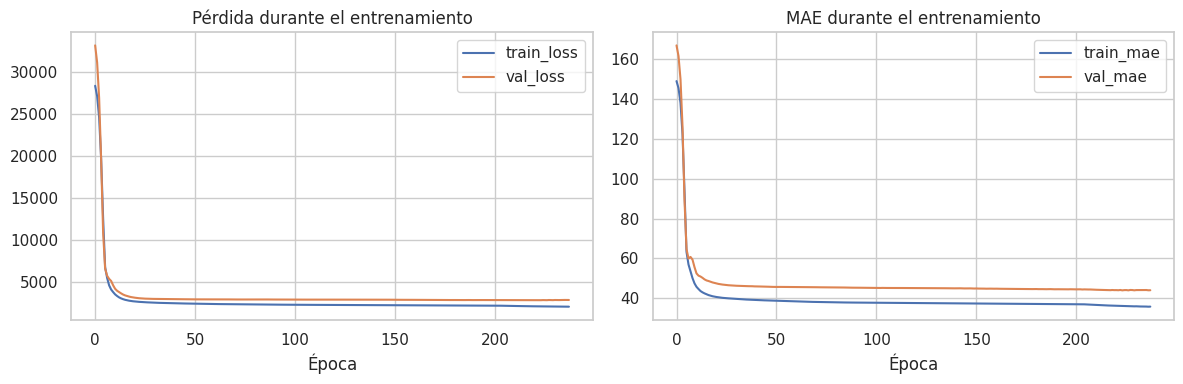

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_reg["loss"], label="train_loss")
ax[0].plot(hist_reg["val_loss"], label="val_loss")
ax[0].set_title("Pérdida durante el entrenamiento")
ax[0].set_xlabel("Época")
ax[0].legend()

ax[1].plot(hist_reg["mae"], label="train_mae")
ax[1].plot(hist_reg["val_mae"], label="val_mae")
ax[1].set_title("MAE durante el entrenamiento")
ax[1].set_xlabel("Época")
ax[1].legend()

plt.tight_layout()
plt.show()

## 29. ¿Cómo leer estas curvas?

### Caso razonable
- la pérdida de entrenamiento baja,
- la de validación también baja,
- y ambas se estabilizan sin separarse demasiado.

### Posible overfitting
- entrenamiento sigue mejorando mucho,
- validación deja de mejorar o empeora.

### Posible underfitting
- ambas curvas se quedan altas,
- el modelo parece no tener capacidad suficiente.

No se trata de buscar curvas "perfectas", sino de aprender a leer la historia del entrenamiento.

In [17]:
test_loss_reg, test_mae_reg = model_reg.evaluate(X_test_reg_scaled, y_test_reg, verbose=0)
pred_reg = model_reg.predict(X_test_reg_scaled, verbose=0).ravel()

rmse_reg = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
r2_reg = r2_score(y_test_reg, pred_reg)

print(f"Keras regression -> Test loss (MSE): {test_loss_reg:.3f}")
print(f"Keras regression -> Test MAE: {test_mae_reg:.3f}")
print(f"Keras regression -> Test RMSE: {rmse_reg:.3f}")
print(f"Keras regression -> Test R2: {r2_reg:.3f}")

Keras regression -> Test loss (MSE): 2841.559
Keras regression -> Test MAE: 42.313
Keras regression -> Test RMSE: 53.306
Keras regression -> Test R2: 0.464


In [18]:
results_reg = pd.DataFrame({
    "modelo": ["LinearRegression (baseline)", "Keras MLP"],
    "RMSE": [rmse_linreg, rmse_reg],
    "MAE": [mae_linreg, test_mae_reg],
    "R2": [r2_linreg, r2_reg]
})

results_reg

,modelo,RMSE,MAE,R2
0,LinearRegression (baseline),53.952415,42.907592,0.450589
1,Keras MLP,53.306278,42.313305,0.463670


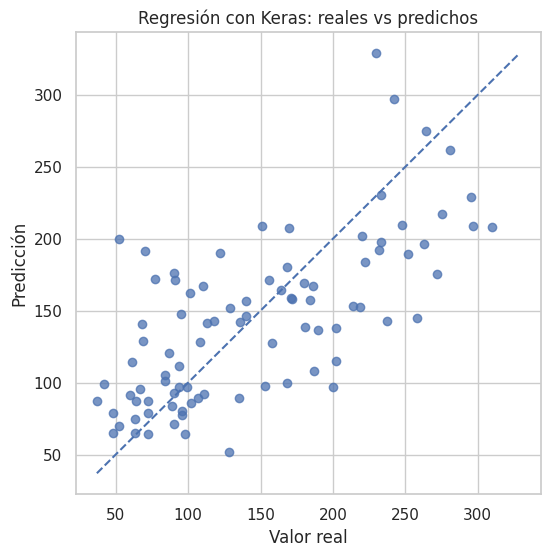

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_reg, alpha=0.75)
lims = [
    min(y_test_reg.min(), pred_reg.min()),
    max(y_test_reg.max(), pred_reg.max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión con Keras: reales vs predichos")
plt.show()

## 30. Lectura pedagógica del ejemplo de regresión

Hay varias lecciones valiosas aquí:

1. **Keras es muy accesible** para montar una red básica.
2. La red aprende de forma iterativa y podemos observar ese aprendizaje.
3. En tabular, una red sencilla no garantiza ganar a un baseline clásico.
4. La comparación justa con `scikit-learn` sigue siendo una excelente práctica.

Esto enlaza de forma directa con el mensaje del módulo:  
**Deep Learning amplía nuestro repertorio, pero no invalida el criterio aprendido con ML clásico**.

# Parte D. Ejemplo 2 — Clasificación tabular con `Keras`

## 31. Dataset de clasificación: `breast_cancer`

Para clasificación vamos a usar el dataset `breast_cancer` de `scikit-learn`, que ya conoces de la sesión 2.

Eso es muy útil porque así el alumnado puede concentrarse en lo nuevo:

- la arquitectura de la red,
- la función de pérdida,
- la activación de salida,
- el entrenamiento,
- y la lectura de las curvas.

In [20]:
breast = load_breast_cancer(as_frame=True)
df_clf = breast.frame.copy()

print(df_clf.shape)
df_clf.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [21]:
X_clf = df_clf.drop(columns="target")
y_clf = df_clf["target"]

print("Clases:", breast.target_names)
print(y_clf.value_counts())

Clases: ['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


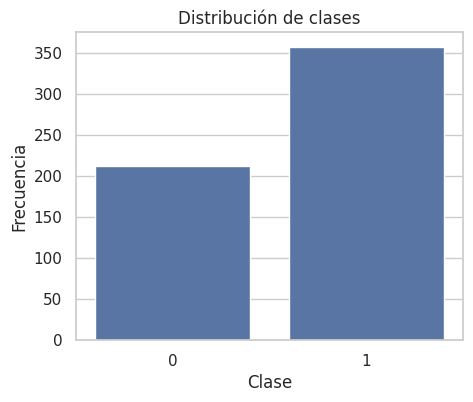

In [22]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y_clf)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

## 32. Preparación de datos

Repetimos un patrón muy parecido al anterior:

- separar train / validation / test,
- escalar variables,
- mantener una evaluación final honesta.

Una de las mejores formas de aprender Deep Learning es comprobar que muchas buenas prácticas **no cambian**.

In [23]:
X_train_full_clf, X_test_clf, y_train_full_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, stratify=y_clf, random_state=42
)

X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_train_full_clf, y_train_full_clf, test_size=0.20, stratify=y_train_full_clf, random_state=42
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_val_clf_scaled = scaler_clf.transform(X_val_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Train:", X_train_clf_scaled.shape)
print("Validation:", X_val_clf_scaled.shape)
print("Test:", X_test_clf_scaled.shape)

Train: (364, 30)
Validation: (91, 30)
Test: (114, 30)


## 33. Un baseline clásico para no perder el norte

Antes de la red, vamos a crear una `LogisticRegression`, que en este dataset suele ser un baseline muy competitivo.

Esto nos ayuda a recordar algo muy importante:

> En datos tabulares, una red neuronal pequeña no siempre superará a un modelo clásico bien montado.

In [24]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

logreg.fit(X_train_clf, y_train_clf)
pred_logreg = logreg.predict(X_test_clf)

acc_logreg = accuracy_score(y_test_clf, pred_logreg)
print(f"Baseline LogisticRegression -> accuracy: {acc_logreg:.4f}")

Baseline LogisticRegression -> accuracy: 0.9825


## 34. Arquitectura para clasificación binaria

En clasificación binaria es muy habitual usar:

- capa(s) oculta(s) con `relu`,
- una sola neurona de salida,
- activación `sigmoid`.

¿Por qué `sigmoid`?

Porque transforma la salida en un valor entre 0 y 1, que podemos interpretar como una probabilidad aproximada de pertenecer a la clase positiva.

In [25]:
model_clf = keras.Sequential([
    layers.Input(shape=(X_train_clf_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_clf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 35. `binary_crossentropy` y `accuracy`

Aquí elegimos:

- **loss = binary_crossentropy**
- **optimizer = Adam**
- **metric = accuracy**

La pérdida es la guía del aprendizaje.  
La accuracy nos da una lectura rápida, aunque no siempre suficiente en todos los problemas.

In [26]:
model_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stop_clf = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_clf = model_clf.fit(
    X_train_clf_scaled,
    y_train_clf,
    validation_data=(X_val_clf_scaled, y_val_clf),
    epochs=300,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop_clf]
)

print(f"Épocas realmente ejecutadas: {len(history_clf.history['loss'])}")

Épocas realmente ejecutadas: 45


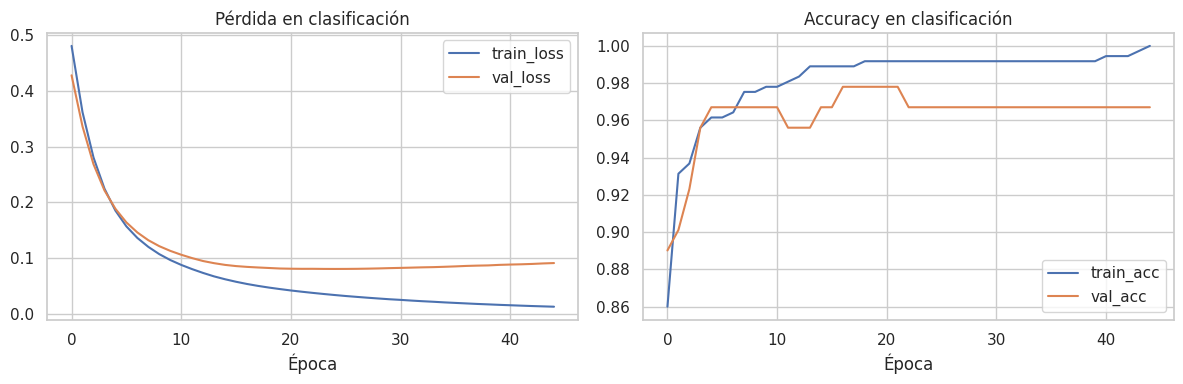

In [28]:
hist_clf = pd.DataFrame(history_clf.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_clf["loss"], label="train_loss")
ax[0].plot(hist_clf["val_loss"], label="val_loss")
ax[0].set_title("Pérdida en clasificación")
ax[0].set_xlabel("Época")
ax[0].legend()

ax[1].plot(hist_clf["accuracy"], label="train_acc")
ax[1].plot(hist_clf["val_accuracy"], label="val_acc")
ax[1].set_title("Accuracy en clasificación")
ax[1].set_xlabel("Época")
ax[1].legend()

plt.tight_layout()
plt.show()

## 36. `predict` y umbral de decisión

Cuando el modelo tiene una salida sigmoide, `predict` devuelve valores entre 0 y 1.

Para convertirlos en clase solemos usar un umbral, normalmente `0.5`:

- si la probabilidad >= 0.5 → clase 1
- si la probabilidad < 0.5 → clase 0

Esto conecta directamente con lo visto en la sesión 2 sobre clasificación.

In [29]:
proba_clf = model_clf.predict(X_test_clf_scaled, verbose=0).ravel()
pred_clf = (proba_clf >= 0.5).astype(int)

acc_clf = accuracy_score(y_test_clf, pred_clf)
print(f"Keras MLP -> accuracy: {acc_clf:.4f}")

Keras MLP -> accuracy: 0.9474


In [30]:
print(classification_report(y_test_clf, pred_clf, target_names=breast.target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



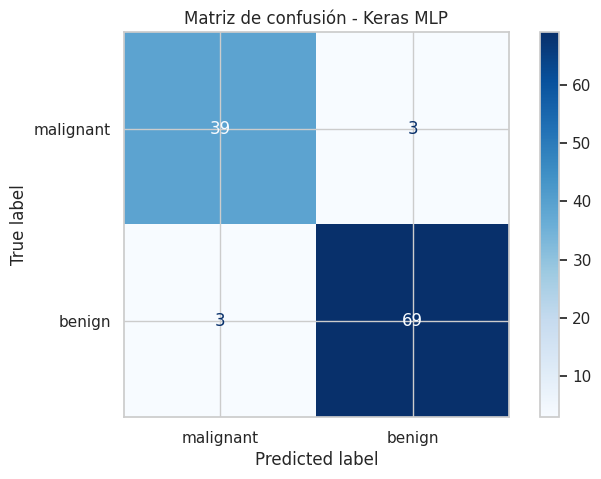

In [31]:
cm = confusion_matrix(y_test_clf, pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=breast.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Keras MLP")
plt.show()

In [32]:
results_clf = pd.DataFrame({
    "modelo": ["LogisticRegression (baseline)", "Keras MLP"],
    "accuracy_test": [acc_logreg, acc_clf]
})

results_clf

,modelo,accuracy_test
0,LogisticRegression (baseline),0.982456
1,Keras MLP,0.947368


## 37. Lectura pedagógica del ejemplo de clasificación

Aquí podemos reforzar varias ideas:

- `Keras` no sustituye a la lógica de evaluación.
- La red aprende en función de una pérdida concreta.
- La activación de salida depende del tipo de problema.
- Las métricas siguen siendo imprescindibles.
- En tabular, el benchmark clásico sigue siendo una referencia muy valiosa.

# Parte E. Ejemplo 3 — CNN con MNIST

## 38. ¿Por qué ahora una CNN?

Hasta ahora hemos usado redes **densas** para datos tabulares.

Pero una imagen no es simplemente una lista plana de píxeles.  
Una imagen tiene:

- estructura espacial,
- patrones locales,
- bordes,
- texturas,
- formas.

Las **CNN** (*Convolutional Neural Networks*) están diseñadas precisamente para explotar esa estructura.

## 39. Intuición de una CNN

### Convolución
Una capa convolucional aplica pequeños filtros sobre regiones locales de la imagen.

### Feature maps
Cada filtro genera un mapa de activación que responde a ciertos patrones.

### Pooling
Reduce tamaño espacial y ayuda a concentrar información importante.

### Capa densa final
Tras extraer características, terminamos con capas densas para clasificar.

No hace falta dominar toda la matemática para empezar a trabajar con ellas, pero sí conviene entender su lógica general.

## 40. Dataset MNIST

MNIST es un clásico para introducir visión por computador:

- imágenes de dígitos manuscritos,
- tamaño `28 x 28`,
- escala de grises,
- 10 clases (los dígitos del 0 al 9).

Es un dataset muy cómodo porque:

- se descarga fácilmente desde `tf.keras.datasets`,
- es pequeño,
- y permite concentrarse en la arquitectura y el entrenamiento.

In [33]:
(x_train_img, y_train_img), (x_test_img, y_test_img) = keras.datasets.mnist.load_data()

print("x_train:", x_train_img.shape)
print("y_train:", y_train_img.shape)
print("x_test :", x_test_img.shape)
print("y_test :", y_test_img.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


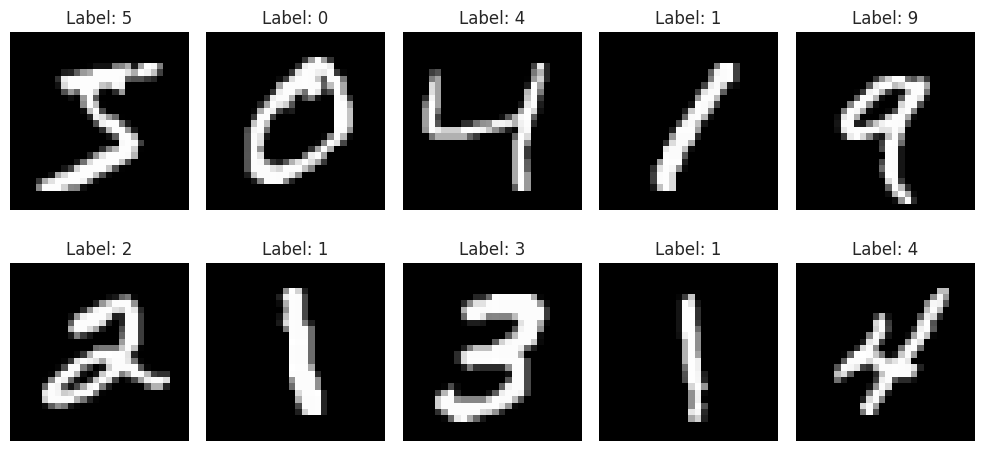

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, img, label in zip(axes.ravel(), x_train_img[:10], y_train_img[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 41. Preparación de imágenes

Aquí hay dos pasos muy típicos:

### a) Normalizar
Pasamos de valores entre `0` y `255` a valores entre `0` y `1`.

### b) Añadir dimensión de canal
Las CNN suelen esperar datos con forma:

`(n_samples, alto, ancho, canales)`

Como MNIST está en gris, el número de canales será `1`.

In [35]:
x_train_img = x_train_img.astype("float32") / 255.0
x_test_img = x_test_img.astype("float32") / 255.0

x_train_img = np.expand_dims(x_train_img, axis=-1)
x_test_img = np.expand_dims(x_test_img, axis=-1)

print("Forma final train:", x_train_img.shape)
print("Forma final test :", x_test_img.shape)

Forma final train: (60000, 28, 28, 1)
Forma final test : (10000, 28, 28, 1)


## 42. Separar validación

Aunque MNIST ya viene con train y test, nos sigue interesando tener un conjunto de validación.

Volvemos a aplicar la misma lógica de siempre.

In [36]:
x_train_cnn, x_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    x_train_img, y_train_img, test_size=0.10, stratify=y_train_img, random_state=42
)

print("Train CNN:", x_train_cnn.shape)
print("Val CNN  :", x_val_cnn.shape)
print("Test CNN :", x_test_img.shape)

Train CNN: (54000, 28, 28, 1)
Val CNN  : (6000, 28, 28, 1)
Test CNN : (10000, 28, 28, 1)


## 43. Arquitectura de una CNN sencilla

Vamos a usar una arquitectura muy introductoria:

- `Conv2D`
- `MaxPooling2D`
- `Conv2D`
- `MaxPooling2D`
- `Flatten`
- `Dense`
- `Dense` final con `softmax`

Como tenemos 10 clases, la salida tendrá 10 neuronas.

In [37]:
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

## 44. `softmax` y `sparse_categorical_crossentropy`

Como cada imagen pertenece a una única clase entre 10 posibles:

- usamos `softmax` en la salida,
- y `sparse_categorical_crossentropy` como pérdida.

¿Por qué `sparse_...`?

Porque nuestras etiquetas están como enteros (`0`, `1`, ..., `9`) y no como vectores one-hot.

In [38]:
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 45. Entrenamiento de la CNN

MNIST es bastante amable, así que con pocas épocas ya suelen verse resultados buenos.

Aun así, mantenemos la lógica de vigilancia con validación y `EarlyStopping`.

In [39]:
early_stop_cnn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train_cnn,
    validation_data=(x_val_cnn, y_val_cnn),
    epochs=10,
    batch_size=128,
    verbose=1,
    callbacks=[early_stop_cnn]
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9104 - loss: 0.3126 - val_accuracy: 0.9702 - val_loss: 0.1105
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9744 - loss: 0.0843 - val_accuracy: 0.9750 - val_loss: 0.0846
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9815 - loss: 0.0614 - val_accuracy: 0.9815 - val_loss: 0.0620
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0497 - val_accuracy: 0.9842 - val_loss: 0.0537
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0423 - val_accuracy: 0.9845 - val_loss: 0.0536
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9893 - loss: 0.0366 - val_accuracy: 0.9838 - val_loss: 0.0549
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9910 - loss: 0.0310 - val_accuracy: 0.9830 - val_loss: 0.0552
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0263 - val_accuracy: 0

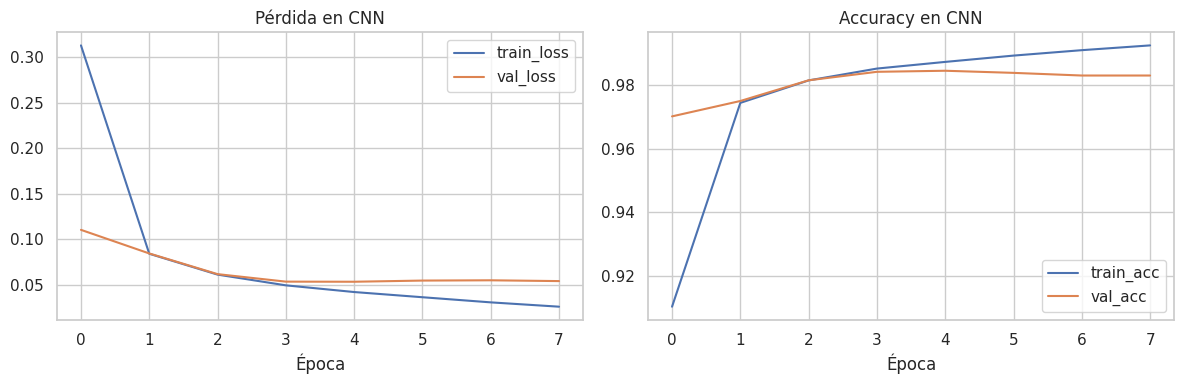

In [41]:
hist_cnn = pd.DataFrame(history_cnn.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_cnn["loss"], label="train_loss")
ax[0].plot(hist_cnn["val_loss"], label="val_loss")
ax[0].set_title("Pérdida en CNN")
ax[0].set_xlabel("Época")
ax[0].legend()

ax[1].plot(hist_cnn["accuracy"], label="train_acc")
ax[1].plot(hist_cnn["val_accuracy"], label="val_acc")
ax[1].set_title("Accuracy en CNN")
ax[1].set_xlabel("Época")
ax[1].legend()

plt.tight_layout()
plt.show()

In [42]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_img, y_test_img, verbose=0)
print(f"CNN -> test loss: {test_loss_cnn:.4f}")
print(f"CNN -> test accuracy: {test_acc_cnn:.4f}")

CNN -> test loss: 0.0399
CNN -> test accuracy: 0.9877


In [44]:
proba_cnn = model_cnn.predict(x_test_img, verbose=0)
pred_cnn = np.argmax(proba_cnn, axis=1)

idx_ok = np.where(pred_cnn == y_test_img)[0]
idx_bad = np.where(pred_cnn != y_test_img)[0]

print("Aciertos:", len(idx_ok))
print("Errores  :", len(idx_bad))

Aciertos: 9877
Errores  : 123


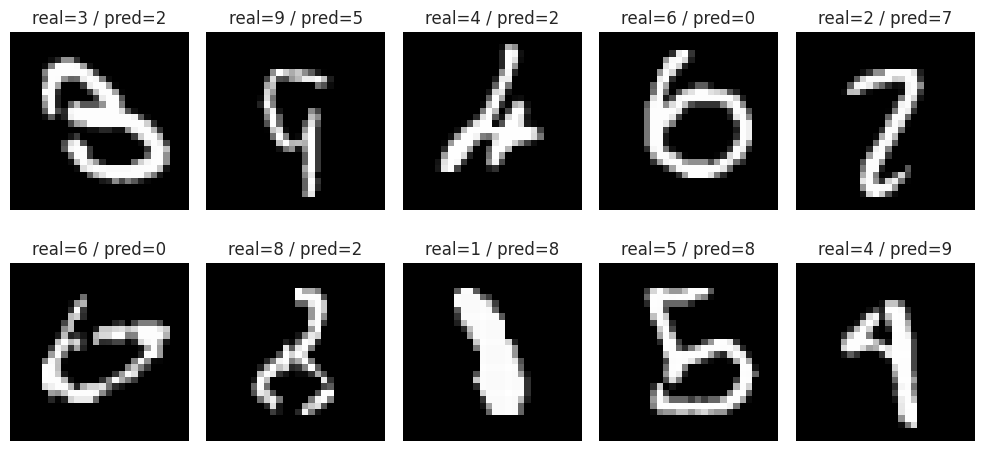

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), idx_bad[:10]):
    ax.imshow(x_test_img[idx].squeeze(), cmap="gray")
    ax.set_title(f"real={y_test_img[idx]} / pred={pred_cnn[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 46. ¿Qué aporta la CNN frente a una red densa simple?

La idea central es que la CNN:

- no trata cada píxel como una variable totalmente aislada,
- aprovecha vecindad local,
- aprende filtros,
- y reutiliza patrones espaciales.

Para imágenes, esta estructura suele ser mucho más adecuada que una MLP densa pura.

# Parte F. Conclusiones y puente hacia la siguiente sesión

## 47. Ideas clave de la sesión

### Conexión con `scikit-learn`
- seguimos necesitando partición de datos,
- seguimos evaluando con métricas,
- seguimos controlando overfitting.

### Fundamentos de Deep Learning
- una red es una composición de capas,
- aprender es minimizar una pérdida,
- el optimizador ajusta pesos iterativamente,
- épocas y batches organizan el entrenamiento.

### Implementación práctica
- `Sequential` permite empezar muy rápido,
- `compile` define el "cómo entrenar",
- `fit` ejecuta el aprendizaje,
- `history` nos deja leer lo que ha pasado.

### Mensaje pedagógico importante
- en tabular, los modelos clásicos siguen siendo muy competitivos,
- en imágenes, las CNN introducen una ventaja estructural clara.

## 48. Errores frecuentes que quiero que evites

1. **Creer que más épocas siempre es mejor**.  
   Puede aumentar el overfitting.

2. **Olvidar el escalado en tabular**.  
   Muchas redes lo agradecen claramente.

3. **Mirar solo la accuracy**.  
   En algunos problemas puede ser insuficiente.

4. **No guardar un conjunto de test limpio**.  
   Sin eso, la evaluación final pierde honestidad.

5. **Comparar una red con un baseline mal hecho**.  
   La comparación justa es parte del método científico en ML.

## 49. Ejercicios propuestos

### Ejercicio 1 — Regresión
Modifica la arquitectura de la red de regresión:
- prueba más o menos neuronas,
- cambia `relu` por otra activación si quieres,
- ajusta el `learning_rate`,
- y observa qué ocurre en las curvas.

### Ejercicio 2 — Clasificación tabular
Prueba:
- una capa más,
- `dropout`,
- distinto `batch_size`,
- o un umbral distinto de `0.5`.

### Ejercicio 3 — CNN
Prueba:
- más filtros,
- otra capa convolucional,
- `Dropout`,
- más épocas,
- y analiza si mejoras o solo empiezas a sobreajustar.

### Ejercicio 4 — Reflexión
Compara los tres casos y responde:
- ¿dónde parece más competitivo el Deep Learning?
- ¿dónde siguen brillando mucho los enfoques clásicos?
- ¿qué señales te dicen que un modelo está sobreajustando?

## 50. Puente hacia la siguiente sesión del módulo

Después de este notebook deberías tener una base razonable para entender:

- cómo se construye una red sencilla,
- cómo se entrena,
- cómo se evalúa,
- y por qué una CNN tiene sentido en visión.

La siguiente sesión natural del módulo puede profundizar en:

- regularización con más detalle,
- arquitecturas más avanzadas,
- transferencia de aprendizaje,
- o comparación más seria entre MLP, CNN y modelos clásicos.